# Избыток в области высокого скора

Рабочий ноутбук. Ниже — схемы источников данных, чтобы не сверяться с кодом каждый раз.

---

## 1. HDF5: `data_manager/data/h5datasets/`

Общая форма — `{group}/{dataset}/part_{...}/data`. Хиты лежат плоско, границы
событий задаёт `ev_starts` (префиксные суммы длины `n_events+1`): событие `i` —
это хиты `[s[i] : s[i+1]]`.

```
{group}/
├── raw/
│   ├── data/{part}/data            (n_hits, 5) float32  [заряд, время, x, y, z]
│   ├── ev_starts/{part}/data       (n_events+1,)
│   ├── channels/{part}/data        (n_hits,) int32      струна = channel // 36
│   ├── cluster_ids/{part}/data     (n_events,) int32
│   ├── labels/{part}/data          (n_hits,) int32      ⚠ значит РАЗНОЕ, см. ниже
│   ├── num_un_strings/{part}/data  (n_events,) int32
│   ├── t_res/{part}/data           (n_hits,) float32    ⚠ только МК
│   ├── reco_mask/{part}/data       (n_hits,) int32      ⚠ только mc_reco
│   └── reco_n_sig_hits/{part}/data (n_events,) int32    ⚠ только mc_reco
├── ev_ids/{part}/data              (n_events,) bytes
├── clusters_centers/{part}/data    (1, 3)
├── coords_are_cluster_centered/data                     True во всех файлах
├── prime_prty/{part}/data          (n_events, 6)        ⚠ только МК
├── muons_prty/{aggregate,individ,mu_starts}/{part}/data ⚠ только МК
├── header_prty/{part}/data                              ⚠ только exp
├── reco_prty/{part}/data                                ⚠ только reco
└── reco_hit_prty/{part}/data       (n_hits, 1) float32  ⚠ только exp_reco
```

| датасет | mc_merged | exp_full | mc_reco | exp_reco |
|---|:-:|:-:|:-:|:-:|
| `raw/data`, `ev_starts`, `channels`, `cluster_ids`, `labels`, `num_un_strings` | ✓ | ✓ | ✓ | ✓ |
| `raw/t_res` | ✓ | · | ✓ | · |
| `raw/reco_mask`, `raw/reco_n_sig_hits` | · | · | ✓ | · |
| `prime_prty`, `muons_prty` | ✓ | · | ✓ | · |
| `header_prty` | · | ✓ (n,6) | · | ✓ (n,4) |
| `reco_prty` | · | · | ✓ (n,31) | ✓ (n,25) |
| `reco_hit_prty` | · | · | · | ✓ |

### Маска реконструкции лежит под разными именами

Побитовая маска BARS — «взят ли хит реконструкцией» — читается из одной ветки
`ScanfitMask.fOrigins.fFlag` в обоих конвертерах, но пишется в разные датасеты,
потому что в МК слот `raw/labels` уже занят истиной:

| | `mc_reco` | `exp_reco` |
|---|---|---|
| маска реконструкции, 0/1 | **`raw/reco_mask`** | **`raw/labels`** |
| счётчик на событие | `raw/reco_n_sig_hits` | нет |
| истина сигнал/шум | `raw/labels`, коды `mcread` (`−999999` и т.п., **не** бинарные) | нет |

Проверено: `raw/reco_n_sig_hits == sum(raw/reco_mask != 0)` совпадает точно; доля
отмеченных хитов 0.130 в МК и 0.135 в эксперименте.

**`reco_hit_prty` = `BRecoMuon.fTRes`**, временнáя невязка хита к треку, `float32`.
В `mc_reco` отсутствует **по конфигу, а не по природе данных**: ключ `reco_hit`
задан в `root2h5_config_exp_reco.yaml` и не задан в `..._mc_reco.yaml`.

### `prime_prty` и `header_prty`

```
prime_prty  (n, 6)  [theta, phi, E_primary, A_primary, ResponseMuonsN, event_weight]
                    углы в градусах, энергия в ГэВ
                    ⚠ одна строка НА КЛАСТЕР — многокластерное событие продублировано

header_prty exp_full  (n, 6)  [season, cluster, run, event_id, sec, nsec]
                              event_id = sec·1e9 + nsec
            exp_reco  (n, 4)  [season, cluster, run, event_id_in_run]
```

### `reco_prty` — 25 скаляров BRecoMuon (в МК плюс 6 векторных)

Имена и порядок в `inference/shared_utils.py`; импортируйте оттуда.

```
 0 thetaRec     1 phiRec       2 thetaErr     3 phiErr       4 funcValue
 5 timeChi2     6 chargeTerm   7 LLFit        8 nHits        9 nStrings
10 nOMs        11 pathLength  12 timeXYZRec  13 covMatrixStatus  14 scfMaxTheta
15 scfMinTheta 16 scfTheta    17 scfPhi      18 pHit        19 evCenterZ
20 zDist       21 nTriplets   22 nCalls      23 classBDT    24 classBDTLowE
                                 только МК: 25–27 xyzRec_{x,y,z}, 28–30 dirRec_{x,y,z}
```

* **единицы смешаны** — `thetaRec`, `phiRec`, `thetaErr`, `phiErr` в **градусах**
  (90° = горизонт, больше = нисходящие); `scf*` — в **радианах**;
* **три поля не заполнены** — `LLFit` ≡ 0, `classBDT` ≡ `classBDTLowE` ≡ −2;
* **`exp` и `mc` ROOT-файлы используют разные начала отсчёта по z.** Проверено
  чтением ROOT напрямую: геометрия ОМ в экспериментальных файлах занимает
  0…629 м со средним **361.7**, в модельных — −264…+268 со средним **0.0**.
  Соответственно `fEvCenterZ` лежит в 0…626 против −234…+238. Конвертер
  `reco_prty` не трогает вовсе, так что различие унаследовано из ROOT.
  Сравнивать можно только `evCenterZ − clusters_centers[part][2]`: тогда медианы
  74.3 и 46.0 вместо 474 и 40. То же касается `xyzRec_z` в МК.

Отдельно: **координаты хитов кластер-центрированы, а `reco_prty` — нет**, поэтому
внутри одного файла `evCenterZ` нельзя сравнивать с `z` хитов без того же сдвига.

Каты качества, доли прохождения и дефекты данных —
в [`doc/reco_quality_cuts.md`](../../../../doc/reco_quality_cuts.md).

### Sig-noise вероятности, рядом с каждым источником

`{источник}_probs_k_nsol_labelneq0_da_hs128_k0p0001.h5`, порядок хитов как в
исходнике:

```
{group}/probs/{part}/data                    (n_hits,) float32
{group}/ev_starts/{part}/data                (n_events+1,)
{group}/channels/{part}/data                 (n_hits,) int32
{group}/n_sig_hits_{0.5,0.8}/{part}/data     (n_events,) int32
{group}/n_sig_strings_{0.5,0.8}/{part}/data  (n_events,) int32
{group}/n_gt_sig_hits/{part}/data            (n_events,) int32   ⚠ только МК
атрибуты: sig_noise_batch_size=256, sig_noise_model=...
```

Размер батча — **не** настройка скорости: он определяет, какие хиты остаются
(`doc/sig_noise_batch_size.md`). Все четыре источника посчитаны при 256.

---

## 2. Каталог: `data_manager/catalog_v2.duckdb`

```
events         id  source  data_class  season  cluster  run:VARCHAR  event_id  feature_hash
h5_locations   event_fk  h5_path  part_key  local_idx
npy_locations  event_fk  npy_dir  npy_tag  local_idx
root_locations event_fk  root_path  local_idx
```

**`h5_locations` — единственный правильный путь от `event_fk` к хитам.** Есть для
100% событий всех источников и обходит три ловушки, каждая из которых уже
приводила к порче данных:

* **`events.run` означает разное** — у `mc_reco` это полное имя части
  (`part_2020_cl7_run1004_scl_nu_MC_s19-21`) при незаполненном `cluster`; у
  `exp_reco` — номер рана строкой (`"465"`) в паре с `cluster`;
* **имена частей МК повторяются между классами** — `muatm` и `nuatm_conv` делят
  223 имени, `nuatm_conv` и `nuatm_prompt` — 1117;
* **`events.event_id` — не позиция в массиве**: у `exp_full` это метка времени, у
  `exp_reco` — физический `event_id_in_run`. Позиция в `h5_locations.local_idx`.

| source | events | classes |
|---|---|---|
| `mc_merged` | 651 308 713 | `muatm_2020`, `nuatm_2020`, `nue2_2020` |
| `exp_full` | 133 294 745 | один |
| `exp_reco` | 14 447 866 | один |
| `mc_reco` | 3 606 696 | `muatm_2020`, `nuatm_conv_2020`, `nuatm_prompt_2020`, `nue2_2020` |

`mc_reco` — **другая продукция**, чем `mc_merged`: пересечение по `feature_hash`
равно нулю.

---

## 3. Базы предсказаний: `preds/{MODEL}/{source}_thr0p8.duckdb`

Все четыре просчитаны чекпойнтом
`260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256@best_da_model`.

| таблица | mc_merged | exp_full | mc_reco | exp_reco |
|---|:-:|:-:|:-:|:-:|
| `predictions` | ✓ | ✓ | ✓ | ✓ |
| `scalars` | ✓ | ✓ | · | · |
| `splits` | ✓ | ✓ | · | · |
| `truth` | ✓ | · | · | · |
| `event_time` | · | ✓ | · | · |
| `direction`, `distances`, `embeddings` | ✓ | ✓ | · | · |
| **событий** | 94 363 339 | 8 231 582 | 2 880 257 | 12 206 340 |

```
predictions   event_fk  score  n_sn_hits  n_sn_strings
              n_sn_* — по хитам с sig-noise вероятностью > 0.8

scalars       event_fk  n_sig_hits  n_sig_strings  n_channels
              q_mean q_std q_total q_max q_frac_max
              r_vert t_span t_span_core z_span xy_span x_c y_c z_c
              prob_mean prob_min
              ⚠ посчитано ПОСЛЕ фильтра — шум отсюда не измерить
              ⚠ заряд КЛИПОВАН на 100 ф.э.: q_max упирается ровно в 100.0,
                поэтому аномальные заряды через него НЕ видны

splits        event_fk  data_class  part_key  local_idx
              used_for_labels  was_da_target  excluded  role

truth         event_fk  zenith_deg  azimuth_deg  primary_energy_gev  event_weight
              ⚠ только mc_merged; event_weight ≡ 1 для muatm

event_time    event_fk  timestamp_ns  seconds_into_run    ⚠ только exp_full
              ⚠ UTC-меткам и абсолютным временам хитов не доверять

direction     event_fk  time_vs_depth  fit_quality  depth_spread_m  apparent_speed
distances     event_fk  distance_to_mc  distance_to_nu  distance_to_mu  (подвыборка)
embeddings    event_fk  embedding:FLOAT[]
```

---

## 4. Что накладывать на каждый источник

Сводка. Ниже — обоснование и цена каждой маски.

| маска | mc_merged | exp_full | mc_reco | exp_reco |
|---|:-:|:-:|:-:|:-:|
| отбор качества **h8s3** | ✓ | ✓ | ✓ | ✓ |
| исключить **обучающие** | ✓ `NOT used_for_labels` | ✓ `NOT was_da_target` | не нужно | не нужно |
| **чёрный список ранов** | нет | ✓ `NOT excluded` | нет | ✓ `cluster != 1` |
| **аномальный заряд** | ? не проверено | ? не проверено | ✓ `max_q ≤ 1e4` | ✓ `max_q ≤ 1e4` |
| **фрагменты многокластерных** | не нужно | — | ✓ `n_gt_sig_hits > 5` | — |
| выбор класса фона | `muatm_2020` | — | `muatm_2020` | — |

### h8s3 — везде

`n_sn_hits >= 8 AND n_sn_strings >= 3`. Это отбор, в котором посчитаны все
прежние результаты; менять его — значит терять сопоставимость.

| источник | до | после h8s3 |
|---|---|---|
| `mc_merged` | 94 363 339 | 23 171 597 |
| `exp_full` | 8 231 582 | 3 353 716 |
| `mc_reco` | 2 880 257 | 1 015 034 *(muatm)* |
| `exp_reco` | 12 206 340 | 6 921 465 |

### Обучающие события

Модель видела `mc_merged` как размеченный источник и `exp_full` как
неразмеченную цель доменной адаптации.

* **`mc_merged`: `NOT s.used_for_labels`** — убирает 2 640 384 события
  (2 426 900 с `role='test'`, 213 484 с `role='reference'`).
* **`exp_full`: `NOT s.was_da_target`** — убирает 5 274 536, то есть **64% базы**.

`mc_reco` и `exp_reco` чистить не нужно, и это **проверено**: пересечение
`mc_reco` с `mc_merged` по `feature_hash` равно нулю, у `exp_reco` с `exp_full`
общих 2 820 событий (0.02%). ⚠ Совпадение хешей не доказывает тождество событий —
для поштучного разбора кандидатов проверять иначе.

### Чёрные списки

**`exp_full`: `NOT s.excluded`** — 425 942 события из двух ранов:

```
part_s2020_c02_r0020   217 978
part_s2020_c02_r0249   207 964
```

В них четыре канала одной струны кластера 2 выдают до 3170 ф.э. при медиане хита
0.97; события, задевающие эти каналы, получают скор > 0.8 в **8.7 раза** чаще.

**`exp_reco`: `cluster != 1`.** Измерено: кластер 1 принимает **6.9%** своих
h8s3-событий против 0.94–1.18% у всех остальных, и лишь 30% его событий доходят
до скора против ~90% у прочих. Влияние на избыток при ξ>0.8: **5.47 с ним против
3.00 без него**.

⚠ В памяти проекта исключение кластера 1 записано как *опровергнутое* — но та
проверка делалась против `exp_full.h5`, а здесь другой файл, и измерение
однозначно. Для `exp_full` кластер 1 исключать не нужно.

### Аномальный заряд

**`max_q ≤ 1e4` ф.э.** — дефект «Bad Qmax» из работы с префильтром. В `exp_reco`
0.20% событий, из них 1.44% в кластере 2 и ровно ноль в кластерах 3 и 6; в
`mc_reco` 0.12%.

⚠ **Через `scalars.q_max` это не поймать** — там заряд клипован на 100 ф.э.
(`compute_scalars.py`, `Q_CLIP`). Максимальный заряд надо считать по сырым хитам:
`np.maximum.reduceat(raw/data[:,0], ev_starts[:-1])`.

Для `mc_merged` и `exp_full` эта проверка **не делалась** — стоит сделать, прежде
чем считать их чистыми.

### Фрагменты многокластерных событий (`mc_reco`)

**`n_gt_sig_hits > 5`** из файла вероятностей. Многокластерное событие хранится
по разу на кластер, и каждый фрагмент несёт реконструкцию **целого** события
рядом с хитами лишь одного куска. У 12% `mc_reco` истинных сигнальных хитов нет
вовсе. Без этой маски сравниваются фрагменты МК с целыми экспериментальными
событиями.

Для `mc_merged` эта маска не нужна: там `reco_prty` нет, и подмены не возникает.

### Выбор класса фона

Фоном может быть **только `muatm`**. В `mc_reco` три из четырёх классов — нейтрино,
и классификатор принимает **99.4–99.9%** из них; включение их в знаменатель
кладёт сигнал в фон. Так же ломается любое сравнение долей прохождения катов: по
всему `mc_reco` кат `thetaRec < 80` выглядит вдесятеро асимметричным, а против
`muatm` его отношение 0.77.

---

## 5. Как исключить события, участвовавшие в обучении

Модель обучалась на двух наборах: размеченный источник — `mc_merged`,
неразмеченная цель доменной адаптации — `exp_full`. Оба помечены в `splits`.

**`mc_merged`: исключать `used_for_labels = TRUE`** — 2 640 384 события
(2 426 900 с `role='test'`, 213 484 с `role='reference'`).

**`exp_full`: исключать `was_da_target = TRUE`** — 5 274 536 событий, то есть
**64% базы**. Отдельно `excluded = TRUE` помечает 425 942 события из двух плохих
ранов `c02` (каналы до 3170 ф.э.) — их тоже стоит убирать.

```sql
-- mc_merged: только не участвовавшие в обучении
SELECT p.event_fk, p.score, s.data_class
FROM predictions p JOIN splits s USING (event_fk)
WHERE NOT s.used_for_labels
  AND p.n_sn_hits >= 8 AND p.n_sn_strings >= 3

-- exp_full: не цель доменной адаптации и не из плохих ранов
SELECT p.event_fk, p.score
FROM predictions p JOIN splits s USING (event_fk)
WHERE NOT s.was_da_target AND NOT s.excluded
  AND p.n_sn_hits >= 8 AND p.n_sn_strings >= 3
```

**`mc_reco` и `exp_reco` чистить не нужно, и это проверено.** По `feature_hash`
из каталога пересечение `mc_reco` с `mc_merged` равно **нулю** — разные продукции
целиком. У `exp_reco` с `exp_full` общих **2 820** событий, 0.02% выборки. Если
чистота критична:

```sql
SELECT e.id FROM cat.events e
WHERE e.source = 'exp_reco'
  AND e.feature_hash NOT IN (
      SELECT feature_hash FROM cat.events WHERE source = 'exp_full')
```

⚠ `feature_hash` — отпечаток содержимого, и совпадение хешей не доказывает
тождество событий: 2 820 из 14.4 млн могут быть коллизиями. Для скоринговых
распределений это ниже уровня значимости; для поштучного разбора кандидатов
проверять иначе.

## Импорты и ссылки на БД

In [1]:
# ── Imports ───────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

import duckdb
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ── Project layout ────────────────────────────────────────────────────────────
# main.ipynb lives at inference_v2/nu_classifier/analysis/HIGH_SCORE_EXCESS/
HERE = Path.cwd()
ROOT = next(p for p in [HERE, *HERE.parents] if (p / "CLAUDE.md").exists())
sys.path.insert(0, str(ROOT))

DATA    = HERE / "data";    DATA.mkdir(exist_ok=True)
FIGURES = HERE / "figures"; FIGURES.mkdir(exist_ok=True)

# Authoritative names of the 25 BRecoMuon scalars in reco_prty (+6 MC vectors).
# Imported rather than retyped so the notebook cannot drift from the pipeline.
from inference.shared_utils import EXP_RECO_COL_NAMES, MC_RECO_COL_NAMES

# ── The scored checkpoint ─────────────────────────────────────────────────────
# All four sources were scored with this one, from stored sig-noise probabilities
# at batch 256. That batch size is not a speed knob: it defines which hits
# survive the filter — see doc/sig_noise_batch_size.md.
MODEL     = "260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256@best_da_model"
PREDS_DIR = ROOT / "inference_v2/nu_classifier/preds" / MODEL
CATALOG   = ROOT / "data_manager/catalog_v2.duckdb"

PREDS = {
    "mc_merged": PREDS_DIR / "mc_merged_thr0p8.duckdb",   # 94,363,339 scored
    "exp_full":  PREDS_DIR / "exp_full_thr0p8.duckdb",    #  8,231,582
    "mc_reco":   PREDS_DIR / "mc_reco_thr0p8.duckdb",     #  2,880,257
    "exp_reco":  PREDS_DIR / "exp_reco_thr0p8.duckdb",    # 12,206,340
}

# The four databases are NOT alike. The reco ones hold predictions and nothing
# else, so their data class, cluster and run come from the catalog.
TABLES = {
    "mc_merged": ["predictions", "scalars", "splits", "truth",
                  "direction", "distances", "embeddings"],
    "exp_full":  ["predictions", "scalars", "splits", "event_time",
                  "direction", "distances", "embeddings"],
    "mc_reco":   ["predictions"],
    "exp_reco":  ["predictions"],
}

# ── Source HDF5 and the sig-noise probabilities beside them ───────────────────
H5DIR  = ROOT / "data_manager/data/h5datasets"
SN_TAG = "k_nsol_labelneq0_da_hs128_k0p0001"
H5 = {
    "mc_merged": H5DIR / "baikal_mc_merged.h5",
    "exp_full":  H5DIR / "exp_full.h5",
    "mc_reco":   H5DIR / "baikal_mc_reco.h5",
    "exp_reco":  H5DIR / "exp_reco.h5",
}
PROBS = {name: H5DIR / f"{path.stem}_probs_{SN_TAG}.h5" for name, path in H5.items()}

# Top-level HDF5 groups. mc_reco is a different production from mc_merged: no
# year suffix, and the atmospheric neutrinos are split conventional / prompt.
# Verified: the two share zero events by catalog feature_hash.
GROUPS = {
    "mc_merged": ["muatm_2020", "nuatm_2020", "nue2_2020"],
    "exp_full":  ["exp_full"],
    "mc_reco":   ["muatm", "nuatm_conv", "nuatm_prompt", "nue2"],
    "exp_reco":  ["exp_reco"],
}

# The BARS per-hit reconstruction mask (0/1) comes from the same ROOT branch in
# both reco files but lands in a different dataset, because in MC the `labels`
# slot is already taken by the simulation truth:
#   mc_reco   raw/reco_mask   (raw/labels holds mcread source codes, not binary)
#   exp_reco  raw/labels
RECO_HIT_MASK = {"mc_reco": "raw/reco_mask", "exp_reco": "raw/labels"}

# ── Conventions fixed by the pipeline ─────────────────────────────────────────
SN_THRESHOLD    = 0.8    # a hit counts as signal above this probability
SN_BATCH        = 256    # defines the hit selection, not the speed
STRING_DIVISOR  = 36     # string id = channel // 36
QUALITY         = "p.n_sn_hits >= 8 AND p.n_sn_strings >= 3"      # the h8s3 cut

# reco_prty is written in absolute detector coordinates while the hits are
# cluster-centred, and the two files disagree about that origin. Compare
# evCenterZ only after subtracting clusters_centers[2] of the same part.
CLUSTER_CENTRE_Z = {"exp_reco": 361.7, "mc_reco": 0.}   # medians; read per part

# Training exclusion. The model saw mc_merged as the labelled source and
# exp_full as the unlabelled DA target; the reco sources were never used.
TRAIN_FILTER = {
    "mc_merged": "NOT s.used_for_labels",
    "exp_full":  "NOT s.was_da_target AND NOT s.excluded",
    "mc_reco":   None,
    "exp_reco":  None,
}


def connect(source: str, with_catalog: bool = True) -> duckdb.DuckDBPyConnection:
    """Read-only connection to one prediction database, catalog attached as `cat`."""
    con = duckdb.connect(str(PREDS[source]), read_only=True)
    con.execute("PRAGMA threads=8")
    if with_catalog:
        con.execute(f"ATTACH '{CATALOG}' AS cat (READ_ONLY)")
    return con


def scores(source: str, quality: bool = True, drop_training: bool = True,
           extra: str = "") -> pd.DataFrame:
    """event_fk, score, hit counts and identity for one source.

    Identity comes from `splits` where it exists and from the catalog otherwise;
    the catalog's `h5_locations` is the only key that means the same thing for
    every source, so it is what carries part_key and local_idx.
    """
    where = [quality and QUALITY, extra]
    if drop_training and TRAIN_FILTER[source]:
        where.append(TRAIN_FILTER[source])
    clause = " AND ".join(w for w in where if w) or "TRUE"
    joins = "JOIN splits s USING (event_fk)" if "splits" in TABLES[source] else ""
    data_class = "s.data_class" if joins else "e.data_class"
    with connect(source) as con:
        return con.execute(f"""
            SELECT p.event_fk, p.score, p.n_sn_hits, p.n_sn_strings,
                   {data_class} AS data_class, e.cluster, e.run,
                   l.part_key, l.local_idx
            FROM predictions p
            {joins}
            JOIN cat.events e       ON e.id = p.event_fk
            JOIN cat.h5_locations l ON l.event_fk = p.event_fk
            WHERE {clause}
        """).df()


for name, path in PREDS.items():
    assert path.exists(), f"missing prediction DB: {path}"
    assert H5[name].exists() and PROBS[name].exists(), f"missing HDF5 for {name}"
print(f"ROOT  {ROOT}")
print(f"model {MODEL}\n")
for name in PREDS:
    print(f"  {name:<10} {PREDS[name].stat().st_size / 1e9:6.2f} GB  "
          f"tables: {', '.join(TABLES[name])}")


ROOT  /home/albert/Baikal2025
model 260816_2250_da_nu_classifier_exp_full_E1_lambda0.01_FIXED_sn256@best_da_model

  mc_merged   76.42 GB  tables: predictions, scalars, splits, truth, direction, distances, embeddings
  exp_full     6.21 GB  tables: predictions, scalars, splits, event_time, direction, distances, embeddings
  mc_reco      0.05 GB  tables: predictions
  exp_reco     0.21 GB  tables: predictions


# Создадим кэш событий

── Кэш событий ───────────────────────────────────────────────────────────────

Два кэша, а не один. Хиты — 85 % объёма (≈85 хитов на событие, ~4 ГБ на
миллион), а нужны они только для гистограмм по отдельным хитам. Статистики по
событиям считаются в обоих режимах одинаково — проверено побитово по всем
97 колонкам.  

  BIG   1 млн событий на источник, без таблицы хитов  
  HITS  100 тыс. событий с хитами, другой seed — независимая выборка

Прогоняется один раз; дальше draw_or_load читает с диска за доли секунды.
Кэш, снятый с другими настройками, теперь не возвращается молча, а падает с
перечислением расхождений.

In [58]:
import time

import pandas as pd

import excess

BIG  = excess.paths.DATA / "samples_100k"
HITS = excess.paths.DATA / "samples_hits"

t0 = time.time()
S = {name: excess.draw_or_load(name, 100_000, cache=BIG, keep_hits=False)
     for name in excess.SOURCES}
print(f"\n=== статистики: {(time.time() - t0) / 60:.1f} мин ===\n")

t0 = time.time()
H = {name: excess.draw_or_load(name, 100_000, cache=HITS, seed=1)
     for name in excess.SOURCES}
print(f"\n=== хиты: {(time.time() - t0) / 60:.1f} мин ===\n")

# Сверка адресации на всём, что загрузили: пересчитанные из HDF5 счётчики
# сигнальных хитов против записанных в БД. Ноль расхождений или исключение.
for name in excess.SOURCES:
    excess.verify(S[name])
    excess.verify(H[name])

print(pd.DataFrame([
    dict(source=name,
         drawn=s.meta["drawn"],
         eligible=s.meta["eligible_total"],
         share=f'{s.meta["drawn"] / s.meta["eligible_total"]:.0%}',
         parts=s.meta["n_parts"],
         hits_M=round(s.meta["n_hits"] / 1e6, 1),
         minutes=round(s.meta["elapsed_s"] / 60, 1))
    for name, s in S.items()]).to_string(index=False))


[mc_merged]   10.0s  scanning parts done
[mc_merged]   10.0s  25,071,978 eligible in 12,313 parts; 1,563 blocks of 64 over 1,440 parts
[mc_merged]   21.4s  querying 1,440 parts done
[mc_merged]   49.2s  read 1,440 parts, 100,032 events, 8.9M hits
[mc_merged]   49.6s  assembling done
[exp_full]    2.3s  scanning parts done
[exp_full]    2.3s  1,049,948 eligible in 25 parts; 1,563 blocks of 64 over 25 parts
[exp_full]    5.1s  querying 25 parts done
[exp_full]  223.4s  read 25 parts, 100,032 events, 8.1M hits
[exp_full]  223.7s  assembling done
[mc_reco]    1.9s  scanning parts done
[mc_reco]    1.9s  1,257,559 eligible in 23,317 parts; 1,563 blocks of 64 over 1,384 parts
[mc_reco]    3.0s  querying 1,384 parts done
[mc_reco]  107.9s  read 1,384 parts, 93,040 events, 7.9M hits
[mc_reco]  109.1s  assembling done
[exp_reco]    3.2s  scanning parts done
[exp_reco]    3.2s  6,659,624 eligible in 317 parts; 1,563 blocks of 64 over 288 parts
[exp_reco]    9.3s  querying 288 parts done
[exp_rec

KeyboardInterrupt: 

# Поисследуем источники

In [460]:
import excess
BIG  = excess.paths.DATA / "samples_100k"

print(excess.describe())
S = excess.draw_all(100_000, cache=BIG, refresh=False, keep_hits=False)

mc_merged  groups=3  prime=yes reco=no   removed: training
exp_full   groups=1  prime=no  reco=no   removed: training, flagged bad runs
mc_reco    groups=4  prime=yes reco=31   removed: fragments (n_gt_sig_hits > 5)
exp_reco   groups=1  prime=no  reco=25   removed: clusters [1], 2 runs
mc_merged  <Sample mc_merged: 100,032 events, 0 hits, 1440 parts>  eligible=25,071,978
exp_full   <Sample exp_full: 100,032 events, 0 hits, 25 parts>  eligible=1,049,948
mc_reco    <Sample mc_reco: 93,040 events, 0 hits, 1384 parts>  eligible=1,257,559
exp_reco   <Sample exp_reco: 100,032 events, 0 hits, 288 parts>  eligible=6,659,624


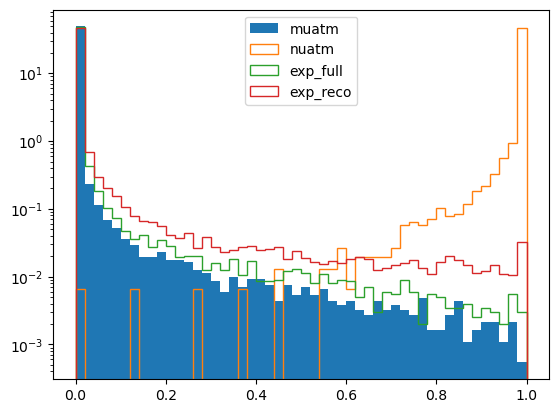

In [461]:
score_exp_full = S['exp_full'].events.score
score_exp_reco = S['exp_reco'].events.score


score_mc_merged = S['mc_merged'].events.score
score_mu_merged = score_mc_merged[S['mc_merged'].events.data_class == 'muatm_2020']
score_nu_merged = score_mc_merged[S['mc_merged'].events.data_class != 'muatm_2020']
plt.hist(score_mu_merged, bins=50, range=(0, 1), density=True, label='muatm', log=True)
plt.hist(score_nu_merged, bins=50, range=(0, 1), density=True, label='nuatm', log=True, histtype='step')
plt.hist(score_exp_full, bins=50, range=(0, 1), density=True, label='exp_full', log=True, histtype='step')
plt.hist(score_exp_reco, bins=50, range=(0, 1), density=True, label='exp_reco', log=True, histtype='step')
plt.legend()
plt.show()

<Axes: >

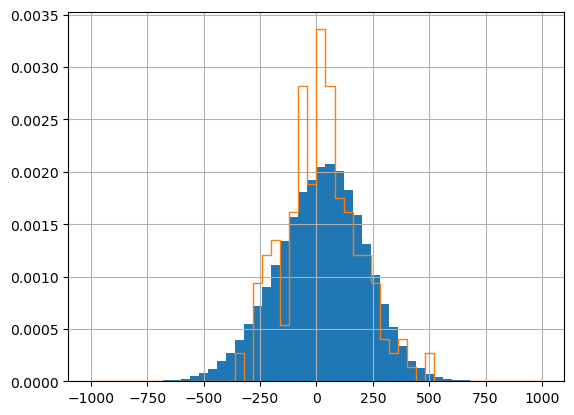

In [462]:
S['exp_full'].events.sig_t_mean.hist(density=True, bins=50, range=(-1000, 1000), label='all exp_full')
S['exp_full'].events[score_exp_full > 0.6].sig_t_mean.hist(density=True, bins=50, range=(-1000, 1000), label='exp_full > 0.6', histtype='step')

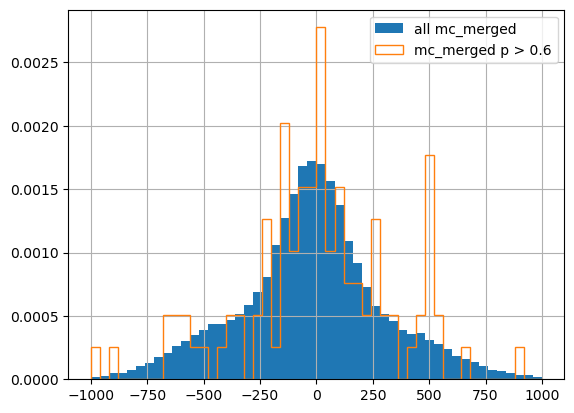

In [463]:
mc_merged_df = S['mc_merged'].events

muatm_df = mc_merged_df[mc_merged_df.data_class == 'muatm_2020']
nuatm_df = mc_merged_df[mc_merged_df.data_class != 'muatm_2020']

muatm_df.sig_t_mean.hist(density=True, bins=50, range=(-1000, 1000), label='all mc_merged')
muatm_df[muatm_df.score > 0.6].sig_t_mean.hist(density=True, bins=50, range=(-1000, 1000), label='mc_merged p > 0.6', histtype='step')
plt.legend()

/tmp/ipykernel_458295/1274559295.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


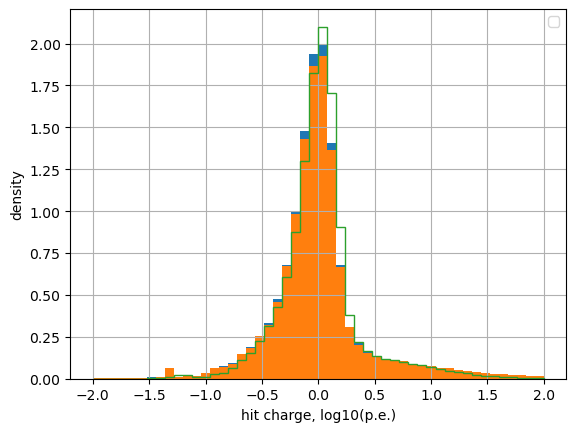

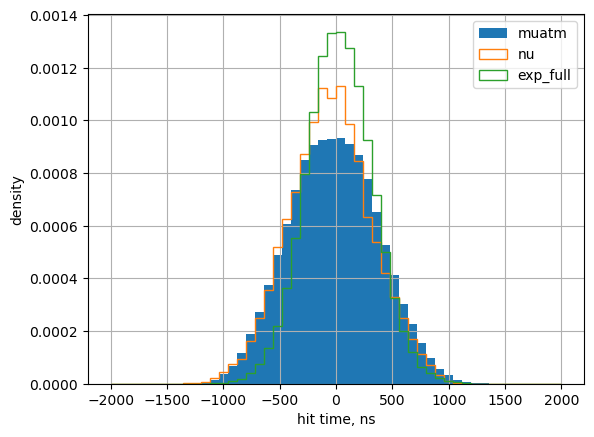

In [6]:
mc_hits = S['mc_merged'].hits
mu_hits = mc_hits[mc_hits.event.isin(muatm_df.index)]
nu_hits = mc_hits[~mc_hits.event.isin(muatm_df.index)]

exp_hits = S['exp_full'].hits

mu_hits.q.apply(np.log10).hist(density=True, bins=50, range=(-2, 2))
nu_hits.q.apply(np.log10).hist(density=True, bins=50, range=(-2, 2))
exp_hits.q.apply(np.log10).hist(density=True, bins=50, range=(-2, 2), histtype='step')
plt.xlabel("hit charge, log10(p.e.)")
plt.ylabel("density")
plt.legend()
plt.show()

mu_hits[mu_hits.is_sig].t.hist(density=True, bins=50, range=(-2000, 2000), label='muatm')
nu_hits[nu_hits.is_sig].t.hist(density=True, bins=50, range=(-2000, 2000), label='nu', histtype='step')
exp_hits[exp_hits.is_sig].t.hist(density=True, bins=50, range=(-2000, 2000), histtype='step', label='exp_full')
plt.xlabel("hit time, ns")
plt.ylabel("density")
plt.legend()
plt.show()

## Sig-noise model probs observation

baseline (20032 ev):   0%|          | 0/20032 [00:00<?, ?it/s]

augmented (20032 ev): 100%|██████████| 20032/20032 [00:00<00:00, 20804.86it/s]


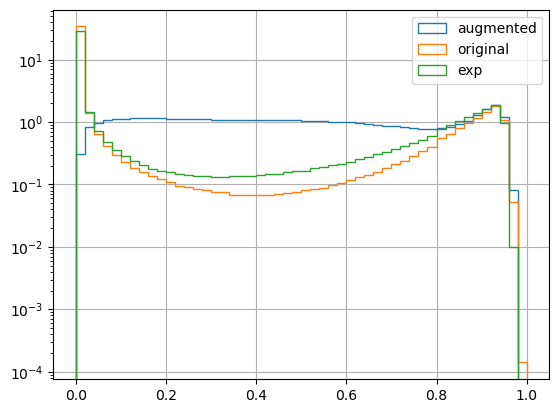

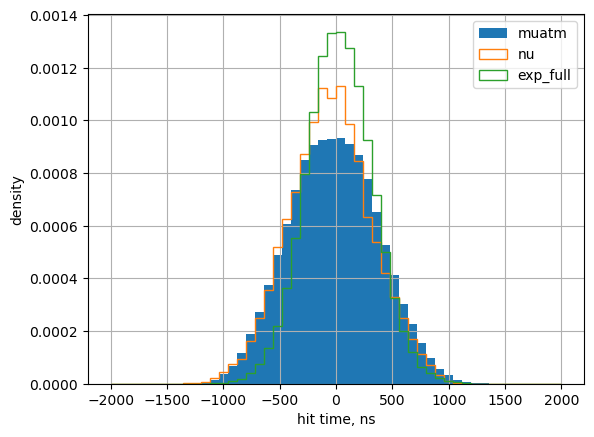

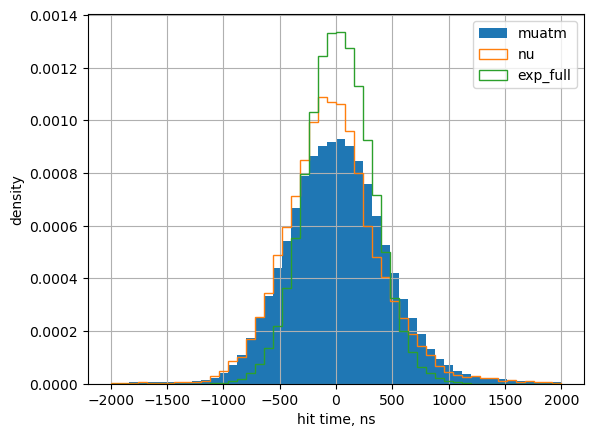

In [45]:
# ── Свежие предсказания sig-noise на аугментированных хитах ───────────────────
# Если торч ещё не импортирован в этом ядре, порядок устройств надо задать до
# первого импорта: PyTorch по умолчанию нумерует карты по скорости, и cuda:1
# может оказаться не той картой, что 1 в nvidia-smi.
import os

from src import data
os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")

import numpy as np
import pandas as pd

import excess

DEVICE = "cuda:0"          # 1.6 мс/событие на CPU: 20 тыс. событий ≈ 30 с на прогон
SEED   = 0

# Аугментация получает КОПИЮ массива (n_hits, 5) в порядке [q, t, x, y, z]
# и возвращает изменённый. Колонка 1 — время в нс, центрированное по событию.
def jitter_time(data, rng, sigma=100.0):
    data[:, 1] += rng.normal(0.0, sigma, len(data)).astype(np.float32)
    return data

def scale_time(data, rng, factor=0.1):
    data[:, 1] *= factor
    return data

S["mc_merged"].hits['prob_aug'] = excess.sn_compare(S["mc_merged"], scale_time, device=DEVICE, seed=SEED)

#sig_mask = S["mc_merged"].hits['prob'] > 0.05
#S["mc_merged"].hits['prob_aug'][sig_mask] = S["mc_merged"].hits['prob'][sig_mask]

S["mc_merged"].hits['prob_aug'].hist(density=True, bins=50, range=(0, 1), histtype='step', label='augmented', log=True)
S["mc_merged"].hits['prob'].hist(density=True, bins=50, range=(0, 1), histtype='step', label='original', log=True)
S["exp_full"].hits['prob'].hist(density=True, bins=50, range=(0, 1), histtype='step', label='exp', log=True)
plt.legend()
plt.show()

mc_hits = S['mc_merged'].hits
mu_hits = mc_hits[mc_hits.event.isin(muatm_df.index)]
nu_hits = mc_hits[~mc_hits.event.isin(muatm_df.index)]
exp_hits = S['exp_full'].hits

mu_hits[mu_hits.is_sig].t.hist(density=True, bins=50, range=(-2000, 2000), label='muatm')
nu_hits[nu_hits.is_sig].t.hist(density=True, bins=50, range=(-2000, 2000), label='nu', histtype='step')
exp_hits[exp_hits.is_sig].t.hist(density=True, bins=50, range=(-2000, 2000), histtype='step', label='exp_full')
plt.xlabel("hit time, ns")
plt.ylabel("density")
plt.legend()
plt.show()

mu_hits[mu_hits.prob_aug>0.8].t.hist(density=True, bins=50, range=(-2000, 2000), label='muatm')
nu_hits[nu_hits.prob_aug>0.8].t.hist(density=True, bins=50, range=(-2000, 2000), label='nu', histtype='step')
exp_hits[exp_hits.is_sig].t.hist(density=True, bins=50, range=(-2000, 2000), histtype='step', label='exp_full')
plt.xlabel("hit time, ns")
plt.ylabel("density")
plt.legend()
plt.show()


In [46]:
mu_hits.is_sig.sum() / len(mu_hits), exp_hits.is_sig.sum() / len(exp_hits)

(np.float64(0.16949593074295977), np.float64(0.19624068871145464))

# High-scored events

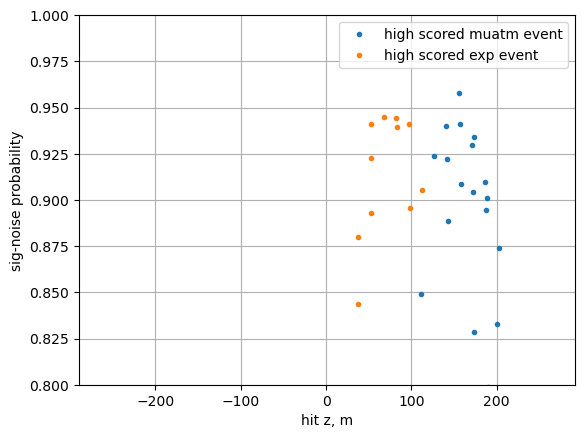

In [450]:
mc_events = S['mc_merged'].events
mc_hits = S['mc_merged'].hits
mu_events = mc_events[mc_events.data_class == 'muatm_2020']
nu_events = mc_events[mc_events.data_class != 'muatm_2020']

exp_events = S['exp_full'].events
exp_hits = S['exp_full'].hits

high_score_mu_1event = mu_events[mu_events.score > 0.6].sample(1)
high_score_probs_1event = mc_hits[mc_hits.event.isin(high_score_mu_1event.index)]
plt.plot(high_score_probs_1event['z'].values, high_score_probs_1event['prob'].values, '.', label='high scored muatm event')

high_score_exp_1event = exp_events[exp_events.score > 0.6].sample(1)
high_score_probs_1event = exp_hits[exp_hits.event.isin(high_score_exp_1event.index)]
plt.plot(high_score_probs_1event['z'].values, high_score_probs_1event['prob'].values, '.', label='high scored exp event')

# low_score_mu_1event = mu_events[mu_events.score < 0.8].sample(1)
# low_score_probs_1event = mc_hits[mc_hits.event.isin(low_score_mu_1event.index)]
# plt.plot(low_score_probs_1event['q'].apply(np.log10).values, low_score_probs_1event['prob'].values, '.', label='low scored muatm event')

# low_score_exp_1event = exp_events[exp_events.score < 0.8].sample(1)
# low_score_probs_1event = exp_hits[exp_hits.event.isin(low_score_exp_1event.index)]
# plt.plot(low_score_probs_1event['q'].apply(np.log10).values, low_score_probs_1event['prob'].values, '.', label='low scored exp event')

plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(True)
plt.xlabel("hit z, m")
plt.ylabel("sig-noise probability")
plt.show()

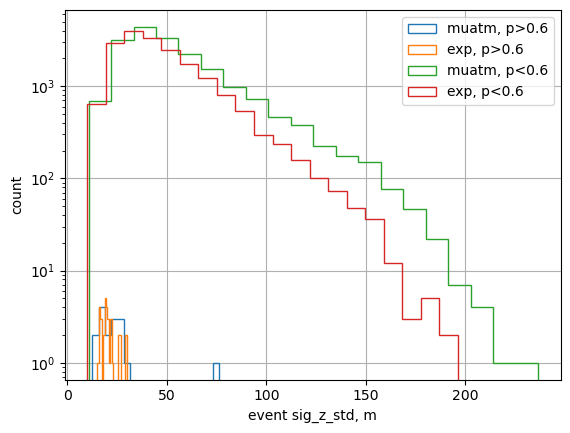

In [515]:
exp_events = S['exp_full'].events.sample(len(mu_events))
#exp_reco_events = S['exp_reco'].events.sample(len(mu_events))
xi_cut = 0.6
column = 'sig_z_std'

mu_events[mu_events.score > xi_cut][column].hist(bins=20, label='muatm, p>0.6', histtype='step', log=True)
exp_events[exp_events.score > xi_cut][column].hist(bins=20, label='exp, p>0.6', histtype='step', log=True)
mu_events[mu_events.score < xi_cut][column].hist(bins=20, label='muatm, p<0.6', histtype='step', log=True)
exp_events[exp_events.score < xi_cut][column].hist(bins=20, label='exp, p<0.6', histtype='step', log=True)
#exp_reco_events[exp_reco_events.score > xi_cut][column].hist(bins=30, label='exp_reco, p>0.6', histtype='step')

plt.xlabel(f"event {column}, m")
plt.ylabel("count")
#plt.xlim(5,50)
plt.legend()



In [512]:
mu_events

,source,group,data_class,part_key,local_idx,event_fk,score,db_n_sn_hits,db_n_sn_strings,cluster,...,sig_y_ptp,sig_z_mean,sig_z_std,sig_z_min,sig_z_max,sig_z_ptp,prob_mean,prob_std,prob_min,prob_max
0,mc_merged,muatm_2020,muatm_2020,part_10049,19221,1785710,0.004410,15,3,2,...,35.914003,-74.654878,122.490767,-263.007996,67.617020,330.625015,0.257103,0.400132,0.002684,0.960484
1,mc_merged,muatm_2020,muatm_2020,part_10049,19249,1785738,0.002432,14,3,5,...,34.001007,189.948984,44.253963,112.924492,262.720459,149.795967,0.240907,0.367847,0.002199,0.946760
2,mc_merged,muatm_2020,muatm_2020,part_10049,19252,1785741,0.002158,18,3,6,...,35.869003,84.912924,92.138698,-68.030586,232.810425,300.841011,0.278058,0.400410,0.002280,0.942470
3,mc_merged,muatm_2020,muatm_2020,part_10049,19262,1785751,0.003799,19,7,4,...,114.640030,196.319301,44.931054,112.375496,262.843506,150.468010,0.239509,0.376069,0.002179,0.941045
4,mc_merged,muatm_2020,muatm_2020,part_10049,19280,1785769,0.002543,12,3,2,...,108.279007,95.070163,113.325063,-82.290009,232.403030,314.693039,0.215962,0.349378,0.002187,0.951532
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18619,mc_merged,muatm_2020,muatm_2020,part_66442,10696,575923404,0.000936,11,4,5,...,104.369019,-201.689778,36.140001,-247.496506,-127.784508,119.711998,0.120221,0.295221,0.002131,0.950066
18620,mc_merged,muatm_2020,muatm_2020,part_66442,10706,575923414,0.001008,11,3,5,...,91.524025,-23.904321,27.331623,-67.690498,22.711491,90.401989,0.159979,0.307116,0.002329,0.928086
18621,mc_merged,muatm_2020,muatm_2020,part_66442,10733,575923441,0.002311,20,4,5,...,114.816986,89.525546,114.950248,-82.295517,262.537506,344.833023,0.201053,0.351573,0.002159,0.938180
18622,mc_merged,muatm_2020,muatm_2020,part_66442,10737,575923445,0.001152,10,3,5,...,29.870979,124.634674,58.375584,37.554501,203.033432,165.478931,0.128131,0.290884,0.002123,0.936900


In [182]:
high_score_probs_1event

,event,q,t,x,y,z,channel,prob,string,is_sig
1042941,13074,0.437862,-2391.022461,49.001617,30.898636,-187.770142,41,0.004888,1,False
1042942,13074,0.153705,-2166.468750,48.151459,30.350861,157.606964,64,0.002820,1,False
1042943,13074,1.034499,-2060.922852,10.528442,56.965057,112.960938,25,0.002904,0,False
1042944,13074,0.628978,-1826.842773,-41.548645,44.142212,-127.378357,225,0.003157,6,False
1042945,13074,1.205806,-1818.068359,52.008331,-21.033249,127.689697,98,0.002940,2,False
1042946,13074,1.682119,-1647.757812,0.690491,-0.684265,202.463837,283,0.002969,7,False
1042947,13074,0.166164,-1592.046875,52.432983,-21.203903,-22.560059,88,0.003118,2,False
1042948,13074,0.545232,-1547.887695,-57.854065,-4.235443,52.779541,201,0.003044,5,False
1042949,13074,0.719994,-1537.141602,10.557831,56.500549,218.078522,32,0.002977,0,False
1042950,13074,0.596184,-1422.235352,-58.131531,-4.201172,-37.357269,195,0.003187,5,False


Index([14462], dtype='int64')

In [65]:
mc_hits[mc_hits.event.isin(high_score_mu_events.index)][['event', 'prob']].groupby('event').

In [61]:
for event, data in mc_hits[mc_hits.event.isin(high_score_mu_events.index)][['event', 'prob']].groupby('event'):#.apply(list)
    print(event, data.prob.values)
    break

232 [0.00318223 0.0033079  0.00356454 0.00348931 0.00325094 0.00324035
 0.00553639 0.01529759 0.0180155  0.02561359 0.03048176 0.03390739
 0.93356574 0.9348279  0.922438   0.0226798  0.94953007 0.9541974
 0.40466273 0.8677778  0.03158796 0.90257764 0.94449395 0.8812812
 0.04188367 0.90340716 0.048156   0.7782803  0.9300251  0.7312883
 0.9275236  0.5488001  0.8977366  0.88795954 0.42472348 0.88231075
 0.77620494 0.39925897 0.3375058  0.04025513 0.04993934 0.19039401
 0.07318547 0.2020424  0.03854423 0.3971009  0.05262578 0.07342864
 0.15201595 0.08836443 0.03742103 0.11687707 0.01004312 0.05169228
 0.02546627 0.05826619 0.05102031 0.04080282 0.02645733 0.01410554
 0.01756228 0.01217658 0.00341896 0.00437839 0.00335487 0.00297674
 0.00303462 0.00300858 0.0029239  0.00297909 0.00286618 0.00290754
 0.00291843 0.00297102 0.00277992 0.00276267 0.00278149 0.0027926
 0.00275492 0.00273685 0.00276203]


In [53]:
mc_hits

,event,q,t,x,y,z,channel,prob,string,is_sig,prob_aug
0,0,0.251977,-2125.934814,-58.110867,-4.861609,232.524933,789,0.003065,21,False,0.071840
1,0,1.047706,-2093.947021,-3.395887,-0.012640,37.707020,848,0.003079,23,False,0.130619
2,0,0.856177,-2068.980469,50.538113,31.678370,-142.584991,620,0.003079,17,False,0.493623
3,0,0.510023,-1795.751343,57.154129,-20.892614,-263.007996,648,0.002759,18,False,0.010904
4,0,0.864407,-1781.130737,-58.110867,-4.861609,112.517021,781,0.002903,21,False,0.333061
...,...,...,...,...,...,...,...,...,...,...,...
1775683,20031,0.452798,2186.071289,-40.877880,41.557365,-127.373016,801,0.010178,22,False,0.251386
1775684,20031,0.722050,2338.049316,-40.877880,41.557365,217.760986,824,0.006834,22,False,0.427997
1775685,20031,1.142701,2348.780762,-31.008856,-49.470634,187.395996,750,0.007010,20,False,0.639573
1775686,20031,0.999649,2474.624268,-58.110867,-4.861609,172.520996,785,0.005411,21,False,0.708841
